In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

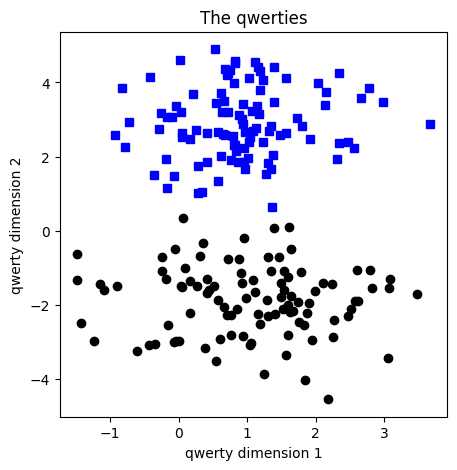

In [9]:
nPerClust = 100
blur = 1

A = [1,3]
B = [1,-2]

a = [ A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur ]

labels_np = np.vstack( ( np.zeros((nPerClust,1)), np.ones((nPerClust,1)) ) )

data_np = np.hstack( (a,b) ).T

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0], data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0], data[np.where(labels==1)[0],1],'ko')
plt.title("The qwerties")
plt.xlabel("qwerty dimension 1")
plt.ylabel("qwerty dimension 2")
plt.show()

In [26]:
# Model
def createANNModel(learningRate):
    ANNclassify = nn.Sequential(
        nn.Linear(2,16), # Input
        nn.ReLU(), # Activation
        nn.Linear(16,1), # Hidden
        nn.ReLU(), # Activation
        nn.Linear(1,1), # Output
        nn.Sigmoid(), # Final
    )
    
    lossfun = nn.BCELoss()
    
    optimizer = torch.optim.SGD(ANNclassify.parameters(), lr=learningRate)
    
    return ANNclassify, lossfun, optimizer

In [27]:
# Train the model
numepochs = 1000

def trainModel(ANNmodel):

    losses = torch.zeros(numepochs)

    for epochi in range(numepochs):

        yHat = ANNmodel(data)

        loss = lossfun(yHat, labels)
        losses[epochi] = loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predictions = ANNmodel(data)

        totalacc = 100*torch.mean( ((predictions>.5) == labels).float() )

        return losses, predictions, totalacc

Final accuracy:  tensor(50.)


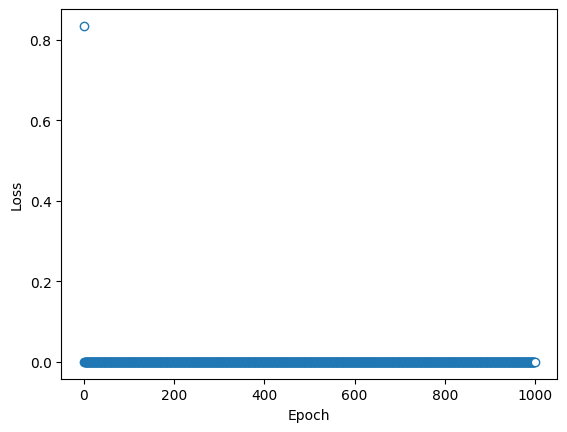

In [28]:
ANNclassify, lossfun, optimizer = createANNModel(.01)

losses, predictions, totalacc = trainModel(ANNclassify)

print(f"Final accuracy: ", totalacc)

plt.plot(losses.detach(), 'o', markerfacecolor='w', linewidth=.1)
plt.xlabel('Epoch'), plt.ylabel('Loss')
plt.show()